# Sparse response modeling for a DSD with scikit-learn

Each row is still a physical experiment; machine learning does not create additional
information. Pydoe or `definitive_screening_design` supplies the planned settings, while
scikit-learn builds candidate terms and selects a sparse predictive model.

This paired example sorts the design rows and uses the same random seed so differences between
the two DSD implementations cannot be hidden by run order or simulated noise. Cross-validation
helps choose the penalty, but with only 26 runs its error estimate is uncertain. Selected terms
are hypotheses for process interpretation and confirmation, not automatic causal findings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LassoCV, lasso_path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import pydoe

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(2026)

In [2]:
factor_names = ["X01", "X02", "X03", "X04", "C01", "C02"]


def make_design(n_fake_factors=6):
    design = pydoe.definitive_screening_design(
        4,
        n_cat=2,
        n_fake_factors=n_fake_factors,
        min_13=True,
    )
    frame = pd.DataFrame(design, columns=factor_names)
    return frame.sort_values(factor_names).reset_index(drop=True)


def response_from_array(x, noise=5.0, random_generator=rng):
    signal = (
        20.0
        + 10.0 * x[:, 0]
        + 8.0 * x[:, 1]
        + 6.0 * x[:, 2]
        + 6.0 * x[:, 4]
        + 8.0 * x[:, 0] * x[:, 1]
        + 15.0 * x[:, 1] * x[:, 2]
        + 10.0 * x[:, 1] * x[:, 4]
        + 5.0 * x[:, 0] ** 2
        + 10.0 * x[:, 3] ** 2
    )
    return signal + random_generator.normal(0, noise, len(x))


data = make_design()
data["Response"] = response_from_array(data[factor_names].to_numpy())
display(data)

,X01,X02,X03,X04,C01,C02,Response
0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,26.034388
1,-1.0,-1.0,-1.0,1.0,1.0,-1.0,31.202856
2,-1.0,-1.0,0.0,1.0,-1.0,1.0,19.518368
3,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,26.978859
4,-1.0,-1.0,1.0,1.0,-1.0,1.0,23.191474
5,-1.0,0.0,1.0,-1.0,1.0,-1.0,35.539763
6,-1.0,1.0,-1.0,-1.0,1.0,1.0,18.440253
7,-1.0,1.0,-1.0,0.0,-1.0,-1.0,-20.480823
8,-1.0,1.0,-1.0,1.0,-1.0,-1.0,-13.338302
9,-1.0,1.0,1.0,-1.0,-1.0,1.0,28.870456


## Cross-validated quadratic Lasso

The pipeline builds all main effects, pure quadratics, and two-factor interactions. Polynomial
columns are standardized after expansion so the L1 penalty is comparable across terms.
`LassoCV` chooses alpha by five-fold cross-validation.

The candidate matrix has more columns than runs. Sparsity makes fitting possible, but correlated
second-order columns can exchange importance. Inspect coefficient paths and retain model
hierarchy when translating a predictive fit into a process model.

In [3]:
candidate_alphas = np.logspace(-3, 1.2, 80)
model = Pipeline([
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(alphas=candidate_alphas, cv=5, max_iter=100000, tol=1e-7)),
])

X = data[factor_names]
y = data["Response"].to_numpy()
model.fit(X, y)

lasso = model.named_steps["lasso"]
print(f"Selected alpha: {lasso.alpha_:.5g}")
print(f"Candidate terms: {len(lasso.coef_)}")

Selected alpha: 0.056811
Candidate terms: 27


## Cross-validation curve and selected effects

The displayed coefficients are converted back from standardized polynomial columns to the original coded-feature scale.

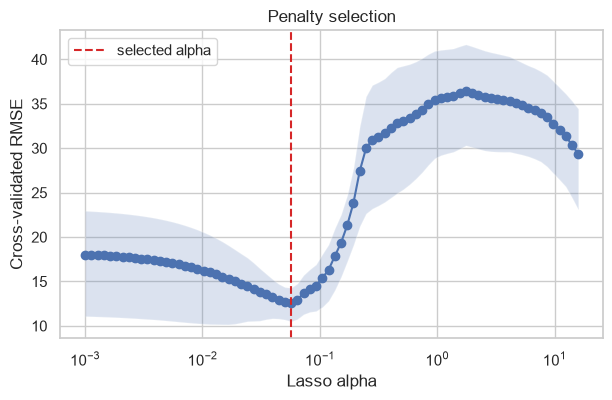

Intercept on original coded scale: 21.328


,effect,coefficient,absolute coefficient
21,X04^2,14.382593,14.382593
13,X02 X03,10.316899,10.316899
0,X01,10.229245,10.229245
7,X01 X02,9.897836,9.897836
1,X02,8.978450,8.978450
2,X03,7.236008,7.236008
4,C01,5.896707,5.896707
15,X02 C01,5.404164,5.404164
18,X03 X04,2.897404,2.897404
22,X04 C01,2.721129,2.721129


In [4]:
mean_cv_error = lasso.mse_path_.mean(axis=1)
standard_error = lasso.mse_path_.std(axis=1, ddof=1) / np.sqrt(lasso.mse_path_.shape[1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(lasso.alphas_, np.sqrt(mean_cv_error), "o-")
ax.fill_between(
    lasso.alphas_,
    np.sqrt(np.maximum(mean_cv_error - standard_error, 0)),
    np.sqrt(mean_cv_error + standard_error),
    alpha=0.2,
)
ax.axvline(lasso.alpha_, color="tab:red", linestyle="--", label="selected alpha")
ax.set(xlabel="Lasso alpha", ylabel="Cross-validated RMSE", title="Penalty selection")
ax.legend()
plt.show()

polynomial = model.named_steps["polynomial"]
scaler = model.named_steps["scaler"]
term_names = polynomial.get_feature_names_out(factor_names)
raw_coefficients = lasso.coef_ / scaler.scale_
raw_intercept = lasso.intercept_ - scaler.mean_ @ raw_coefficients
coefficient_table = pd.DataFrame({
    "effect": term_names,
    "coefficient": raw_coefficients,
    "absolute coefficient": np.abs(raw_coefficients),
}).sort_values("absolute coefficient", ascending=False)

print(f"Intercept on original coded scale: {raw_intercept:.3f}")
display(coefficient_table.query("`absolute coefficient` > 1e-8"))

## Lasso coefficient path

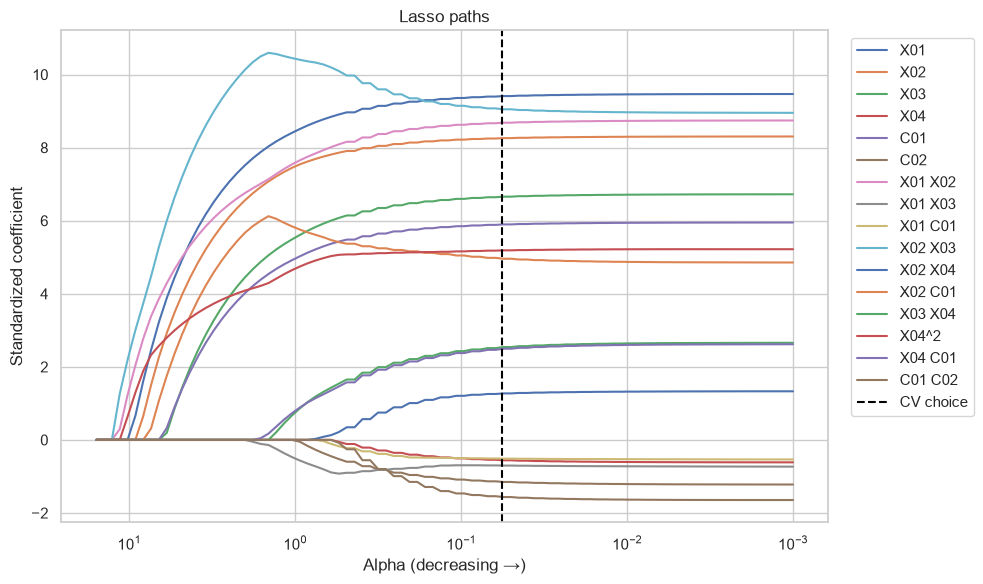

In [5]:
expanded = polynomial.transform(X)
standardized = scaler.transform(expanded)
path_alphas, path_coefficients, _ = lasso_path(
    standardized,
    y - y.mean(),
    alphas=np.logspace(1.2, -3, 90),
    max_iter=100000,
)

fig, ax = plt.subplots(figsize=(10, 6))
for i, name in enumerate(term_names):
    if np.max(np.abs(path_coefficients[i])) > 0.3:
        ax.plot(path_alphas, path_coefficients[i], label=name)
ax.set_xscale("log")
ax.invert_xaxis()
ax.axvline(lasso.alpha_, color="black", linestyle="--", label="CV choice")
ax.set(xlabel="Alpha (decreasing →)", ylabel="Standardized coefficient", title="Lasso paths")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Training and independent-test predictions

The independent test set samples numerical factors uniformly from `[-1,+1]` and categorical factors from `{-1,+1}`. Its response is noiseless, making model-selection bias visible.

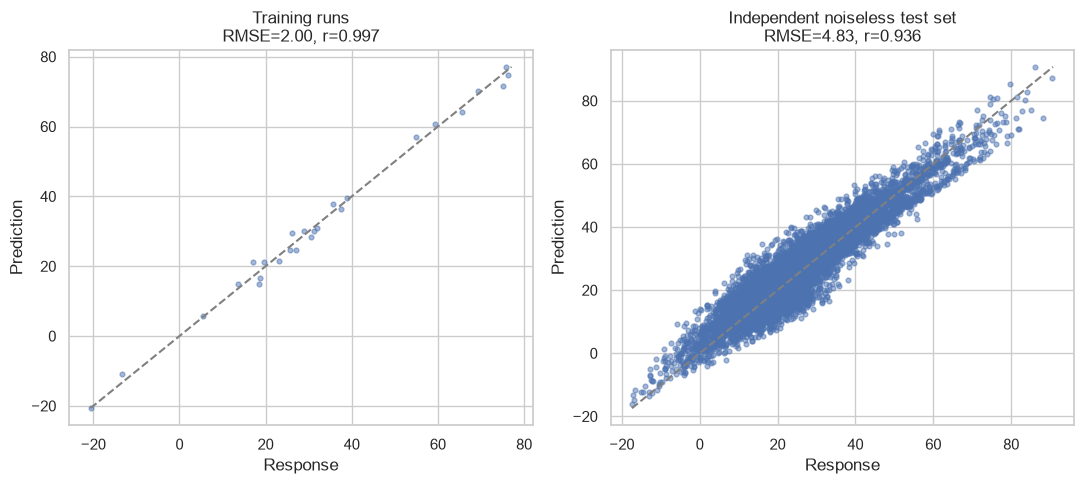

In [6]:
training_prediction = model.predict(X)

test_x = np.column_stack([
    rng.uniform(-1, 1, (10000, 4)),
    rng.choice([-1.0, 1.0], (10000, 2)),
])
test_frame = pd.DataFrame(test_x, columns=factor_names)
test_response = response_from_array(test_x, noise=0.0)
test_prediction = model.predict(test_frame)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, observed, predicted, title in [
    (axes[0], y, training_prediction, "Training runs"),
    (axes[1], test_response, test_prediction, "Independent noiseless test set"),
]:
    ax.scatter(observed, predicted, s=12, alpha=0.5)
    limits = [min(observed.min(), predicted.min()), max(observed.max(), predicted.max())]
    ax.plot(limits, limits, "--", color="gray")
    rmse = np.sqrt(np.mean((observed - predicted) ** 2))
    correlation = stats.pearsonr(observed, predicted).statistic
    ax.set(xlabel="Response", ylabel="Prediction", title=f"{title}\nRMSE={rmse:.2f}, r={correlation:.3f}")

plt.tight_layout()
plt.show()